This notebook is for Exploratory Data Analysis and will have the following components: 
* Load dataset into PySpark DataFrame.
* Perform EDA (missing values, churn distribution, summary stats).
* Visualize churn vs. features (tenure, charges, contract).

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, isnan, count, lit
from pyspark.sql.types import IntegerType, DoubleType, StringType, StructType, StructField

In [2]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Setting up Spark Session
spark = SparkSession.builder \
    .appName("Customer Churn Prediction EDA") \
    .getOrCreate()

In [4]:
# Loading Data
data = spark.read.csv('../data/raw/data.csv', header=True, inferSchema=True)

In [5]:
data.show()

+----------+------+-------------+-------+----------+------+------------+----------------+---------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+--------------+----------------+--------------------+--------------+------------+-----+
|customerID|gender|SeniorCitizen|Partner|Dependents|tenure|PhoneService|   MultipleLines|InternetService|     OnlineSecurity|       OnlineBackup|   DeviceProtection|        TechSupport|        StreamingTV|    StreamingMovies|      Contract|PaperlessBilling|       PaymentMethod|MonthlyCharges|TotalCharges|Churn|
+----------+------+-------------+-------+----------+------+------------+----------------+---------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+--------------+----------------+--------------------+--------------+------------+-----+
|7590-VHVEG|Female|            0|    Yes|        No|     1|  

In [6]:
# Schema of the Data
data.printSchema()

root
 |-- customerID: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- SeniorCitizen: integer (nullable = true)
 |-- Partner: string (nullable = true)
 |-- Dependents: string (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- PhoneService: string (nullable = true)
 |-- MultipleLines: string (nullable = true)
 |-- InternetService: string (nullable = true)
 |-- OnlineSecurity: string (nullable = true)
 |-- OnlineBackup: string (nullable = true)
 |-- DeviceProtection: string (nullable = true)
 |-- TechSupport: string (nullable = true)
 |-- StreamingTV: string (nullable = true)
 |-- StreamingMovies: string (nullable = true)
 |-- Contract: string (nullable = true)
 |-- PaperlessBilling: string (nullable = true)
 |-- PaymentMethod: string (nullable = true)
 |-- MonthlyCharges: double (nullable = true)
 |-- TotalCharges: string (nullable = true)
 |-- Churn: string (nullable = true)



In [7]:
print(f"Number of rows: {data.count()}, Number of columns: {len(data.columns)}")

Number of rows: 7043, Number of columns: 21


In [8]:
# Churn distribution
data.groupBy("Churn").count().show()

+-----+-----+
|Churn|count|
+-----+-----+
|   No| 5174|
|  Yes| 1869|
+-----+-----+



In [9]:
from pyspark.sql.functions import sum

In [10]:
data.select([sum(col(c).isNull().cast("int")).alias(c) for c in data.columns]).show()

+----------+------+-------------+-------+----------+------+------------+-------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------+----------------+-------------+--------------+------------+-----+
|customerID|gender|SeniorCitizen|Partner|Dependents|tenure|PhoneService|MultipleLines|InternetService|OnlineSecurity|OnlineBackup|DeviceProtection|TechSupport|StreamingTV|StreamingMovies|Contract|PaperlessBilling|PaymentMethod|MonthlyCharges|TotalCharges|Churn|
+----------+------+-------------+-------+----------+------+------------+-------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------+----------------+-------------+--------------+------------+-----+
|         0|     0|            0|      0|         0|     0|           0|            0|              0|             0|           0|               0|          0|          0|              0|       0|               0| 

No null values

In [11]:
# Duplicates 
data.select("customerID").distinct().count()

7043

No duplicate customer Id

In [12]:
# Summary statistics
data.describe(["tenure", "MonthlyCharges", "TotalCharges"]).show()

+-------+------------------+------------------+------------------+
|summary|            tenure|    MonthlyCharges|      TotalCharges|
+-------+------------------+------------------+------------------+
|  count|              7043|              7043|              7043|
|   mean| 32.37114865824223| 64.76169246059922|2283.3004408418697|
| stddev|24.559481023094442|30.090047097678482| 2266.771361883145|
|    min|                 0|             18.25|                  |
|    max|                72|            118.75|             999.9|
+-------+------------------+------------------+------------------+



1. Tenure (0–72 months, avg ≈ 32 months)
    * Customers stay for an average of ~2.7 years.
    * Some customers have just joined (tenure = 0), while the longest stay is 6 years.
    * Wide spread (std ≈ 25) shows big differences in customer lifetimes.

2. Monthly Charges (18.25–118.75, avg ≈ 65)
    * On average, customers pay about $65/month.
    * Lowest plan is very cheap ($18), while the highest is nearly $120.
    * Std ≈ 30 → clear variation in pricing plans (basic vs premium).

3. Total Charges (mean ≈ 2283, max ≈ 9999)
    * Average lifetime revenue per customer is ~$2,283.
    * Std ≈ 2267 suggests a very skewed distribution (some very high-value customers).
     The min is blank ("") → indicates missing or incorrect values (probably for tenure = 0).

**Initial Inference**: Churn is likely concentrated among new customers with short tenure and/or high monthly charges. Loyal, high total-charge customers are less likely to churn.

In [13]:
data.groupBy("Churn").avg("MonthlyCharges").show()

+-----+-------------------+
|Churn|avg(MonthlyCharges)|
+-----+-------------------+
|   No|   61.2651236953999|
|  Yes|   74.4413322632423|
+-----+-------------------+



Customers who churn tend to pay higher monthly charges (~$74) compared to those who stay (~$61), suggesting higher costs may increase churn risk.

In [14]:
# Count categorical values
data.groupBy("Contract").count().show()
data.groupBy("PaymentMethod").count().show()

+--------------+-----+
|      Contract|count|
+--------------+-----+
|Month-to-month| 3875|
|      One year| 1473|
|      Two year| 1695|
+--------------+-----+

+--------------------+-----+
|       PaymentMethod|count|
+--------------------+-----+
|Credit card (auto...| 1522|
|        Mailed check| 1612|
|Bank transfer (au...| 1544|
|    Electronic check| 2365|
+--------------------+-----+



Most of the subscriptions are on a monthly basis and the most used payment method is through electronic checks.

In [15]:
# Churn by contract type
data.groupBy("Contract", "Churn").count().orderBy("Contract").show()

# Average tenure by churn
data.groupBy("Churn").avg("tenure").show()


+--------------+-----+-----+
|      Contract|Churn|count|
+--------------+-----+-----+
|Month-to-month|   No| 2220|
|Month-to-month|  Yes| 1655|
|      One year|   No| 1307|
|      One year|  Yes|  166|
|      Two year|  Yes|   48|
|      Two year|   No| 1647|
+--------------+-----+-----+

+-----+------------------+
|Churn|       avg(tenure)|
+-----+------------------+
|   No| 37.56996521066873|
|  Yes|17.979133226324237|
+-----+------------------+



- Contract Type & Churn: Customers on month-to-month contracts have the highest churn (1,655), while longer-term contracts (one or two years) have much lower churn, indicating contract length reduces churn risk.

- Tenure & Churn: Customers who churn have a much shorter average tenure (~18 months) compared to those who stay (~38 months), showing that newer customers are more likely to leave.

In [16]:
# Correlation between numerical features
from pyspark.sql.functions import corr

data.select(corr("tenure", "MonthlyCharges")).show()

+----------------------------+
|corr(tenure, MonthlyCharges)|
+----------------------------+
|         0.24789985628615094|
+----------------------------+



In [17]:
data = data.withColumn("TotalCharges", when(col("TotalCharges") == " ", None).otherwise(col("TotalCharges")))

# Step 2: Cast to double
data = data.withColumn("TotalCharges", col("TotalCharges").cast("double"))

# Step 3: Drop nulls (optional, or you can impute them)
data = data.na.drop(subset=["TotalCharges"])

# Now correlation works
data.select(corr("tenure", "TotalCharges")).show()

+--------------------------+
|corr(tenure, TotalCharges)|
+--------------------------+
|        0.8258804609332019|
+--------------------------+



- Tenure vs Monthly Charges (0.25) → Weak positive correlation: longer-tenured customers tend to pay slightly higher monthly charges, but the relationship is not strong.

- Tenure vs Total Charges (0.83) → Strong positive correlation: as expected, customers who stay longer accumulate much higher total charges.

<Figure size 800x500 with 0 Axes>

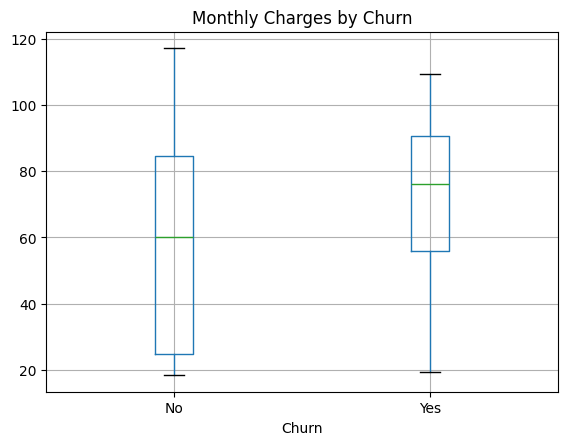

In [18]:
# Visualizations

## Converting to Pandas for visualization
sample_data = data.sample(withReplacement=False, fraction=0.1, seed=42).toPandas()

# Distribution of Monthly Charges
plt.figure(figsize=(8,5))
sample_data.boxplot(column="MonthlyCharges", by="Churn")
plt.title("Monthly Charges by Churn")
plt.suptitle("")
plt.show()

- Median monthly charge: Customers who churn (Yes) have a higher median (~$76) compared to those who stay (No, ~ $60).

- Interquartile range (IQR): Churned customers also have a higher spread in monthly charges, indicating that higher-paying customers are more prone to leave.

- Whiskers & outliers: Both groups have a similar lower bound (~$18–$20), but churned customers reach higher maximum charges (~$110–$118).

In [19]:
print(f"Number of rows: {data.count()}, Number of columns: {len(data.columns)}")

Number of rows: 7032, Number of columns: 21


In [25]:
data_pd_cleaned = data.toPandas()


In [33]:
data_pd_cleaned.to_csv('../data/cleaned/cleaned_data.csv', index=False, header=True)